In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from pathlib import Path
import sys

working_directory = Path.cwd().resolve()
project_root = next(
    (path for path in (working_directory, *working_directory.parents)
     if (path / "pyproject.toml").is_file() and (path / "src").is_dir()),
    None,
)
if project_root is None:
    raise RuntimeError("Open this notebook from within the project directory.")
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))


# **CHRONOS-2 ETTh1 EXPERIMENT**

In [3]:
from src.models.chronos import Chronos2Forecaster
from src.evaluation.experiment import run_single_forecast

In [4]:
chronos = Chronos2Forecaster()

Loading Chronos-2 from amazon/chronos-2 on cuda


Loading weights:   0%|          | 0/170 [00:00<?, ?it/s]

Chronos-2 loaded


In [5]:
result = run_single_forecast(
    forecaster=chronos,
    dataset_name="ETTh1",
    context_length=512,
    prediction_length=96,
    save_results=True)


Dataset: ETTh1
History shape: (512, 7)
Target shape: (96, 7)

Prediction shape matches target shape.
Forecast does not contain NaN or infinite values.

seasonal_period has been configured for MASE.
Saved:
- Forecast: results/forecasts/chronos2_ETTh1_h96.parquet
- Metrics: results/metrics/chronos2_ETTh1_h96.json


In [6]:
for key, value in result["metrics"].items():
    if key == "mase_per_variable":
        continue
    formatted_value = f"{value:.4f}" if isinstance(value, float) else value
    print(f"{key:25}: {formatted_value}")

mae                      : 1.3032
rmse                     : 1.6230
smape                    : 28.3019
mase                     : 0.9597
dataset                  : ETTh1
model                    : chronos2
context_length           : 512
prediction_length        : 96
inference_time_seconds   : 0.3826


In [7]:
if "mase_per_variable" in result["metrics"]:
    print("MASE by Variables:")
    for var_name, score in result["metrics"]["mase_per_variable"].items():
        formatted_score = f"{score:.4f}" if isinstance(score, float) else score
        print(f"{var_name:10}: {formatted_score}")

MASE by Variables:
HUFL      : 0.8623
HULL      : 1.1896
MUFL      : 0.8566
MULL      : 1.2031
LUFL      : 0.8077
LULL      : 0.6276
OT        : 1.1714


In [8]:
result["prediction_df"].head()

,dataset,model,variable,timestamp,horizon_step,actual,prediction,lower,upper
0,ETTh1,chronos2,HUFL,2018-06-22 20:00:00,1,6.564000,7.734156,6.563862,8.981386
1,ETTh1,chronos2,HUFL,2018-06-22 21:00:00,2,6.564000,8.026466,6.419455,9.356281
2,ETTh1,chronos2,HUFL,2018-06-22 22:00:00,3,9.042000,8.725616,6.995178,10.337739
3,ETTh1,chronos2,HUFL,2018-06-22 23:00:00,4,11.119000,9.912792,7.956967,11.839420
4,ETTh1,chronos2,HUFL,2018-06-23 00:00:00,5,16.476999,10.821527,8.873561,12.811199


In [9]:
ot = result["prediction_df"].query("variable == 'OT'")
ot.head()

,dataset,model,variable,timestamp,horizon_step,actual,prediction,lower,upper
576,ETTh1,chronos2,OT,2018-06-22 20:00:00,1,5.909,5.990816,4.729549,6.898367
577,ETTh1,chronos2,OT,2018-06-22 21:00:00,2,5.979,6.211452,4.870397,7.106030
578,ETTh1,chronos2,OT,2018-06-22 22:00:00,3,5.839,6.644186,5.218537,7.516786
579,ETTh1,chronos2,OT,2018-06-22 23:00:00,4,5.839,6.937630,5.405133,7.859216
580,ETTh1,chronos2,OT,2018-06-23 00:00:00,5,5.346,7.112371,5.526452,8.099115


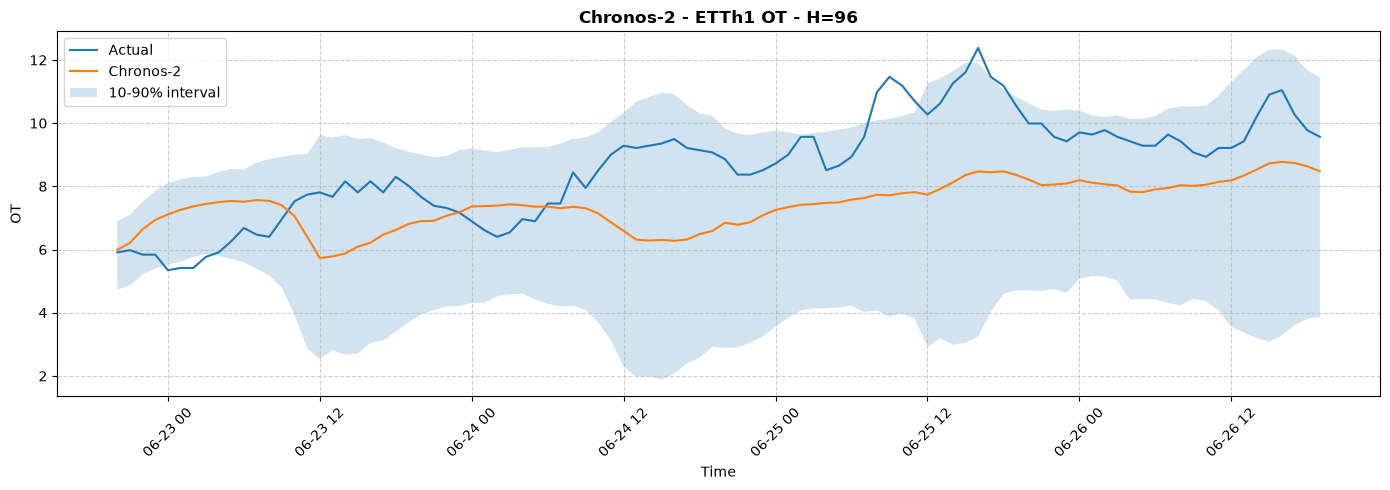

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))
plt.plot(ot["timestamp"], ot["actual"], label="Actual")
plt.plot(ot["timestamp"], ot["prediction"], label="Chronos-2")
plt.fill_between(ot["timestamp"], ot["lower"], ot["upper"], alpha=0.2, label="10-90% interval")

plt.title("Chronos-2 - ETTh1 OT - H=96", fontweight='bold')
plt.xlabel("Time")
plt.ylabel("OT")

plt.legend()
plt.grid(True, alpha=0.6, linestyle='--')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../../results/figures/chronos2_ETTh1_h96.png")
plt.show()

### **Inspect the Result**

In [11]:
import pandas as pd
df = pd.read_parquet('../../results/forecasts/chronos2_ETTh1_h96.parquet')

In [12]:
df.head()

,dataset,model,variable,timestamp,horizon_step,actual,prediction,lower,upper
0,ETTh1,chronos2,HUFL,2018-06-22 20:00:00,1,6.564000,7.734156,6.563862,8.981386
1,ETTh1,chronos2,HUFL,2018-06-22 21:00:00,2,6.564000,8.026466,6.419455,9.356281
2,ETTh1,chronos2,HUFL,2018-06-22 22:00:00,3,9.042000,8.725616,6.995178,10.337739
3,ETTh1,chronos2,HUFL,2018-06-22 23:00:00,4,11.119000,9.912792,7.956967,11.839420
4,ETTh1,chronos2,HUFL,2018-06-23 00:00:00,5,16.476999,10.821527,8.873561,12.811199


In [13]:
df.shape

(672, 9)